# Sentiment Classification of IMDb Movie Reviews using RNN, LSTM and Fine-Tuned GloVe

## 0. Environment Setup


In [1]:
# Core NLP and modelling dependencies
!pip -q install contractions gensim gradio wordcloud

print("Required packages are installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
Required packages are installed.


In [2]:
import os
import re
import time
import random
import zipfile
import warnings
from glob import glob
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.20.0
GPU available: True


## 1. Load Dataset


In [3]:
from google.colab import drive

drive.mount("/content/drive")
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [4]:

ZIP_FILE_PATH = "/content/drive/MyDrive/movie_review.zip"
EXTRACT_DIR = "/content/imdb_movie_review_dataset"

if not os.path.exists(ZIP_FILE_PATH):
    raise FileNotFoundError(
        "Dataset ZIP not found."
    )

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

csv_files = glob(os.path.join(EXTRACT_DIR, "**", "*.csv"), recursive=True)
print("CSV files found:")
for path in csv_files:
    print("-", path)

CSV files found:
- /content/imdb_movie_review_dataset/5. Movie Review Dataset/val_movie_review.csv
- /content/imdb_movie_review_dataset/5. Movie Review Dataset/train_movie_review.csv
- /content/imdb_movie_review_dataset/5. Movie Review Dataset/test_movie_review.csv


In [5]:
def locate_csv(keyword):
    """Return the CSV file whose filename contains the requested keyword."""
    matches = [p for p in csv_files if keyword.lower() in os.path.basename(p).lower()]
    if not matches:
        raise FileNotFoundError(f"Could not find a CSV file containing: {keyword}")
    return matches[0]

train_path = locate_csv("train")
val_path = locate_csv("val")
test_path = locate_csv("test")

train_raw = pd.read_csv(train_path)
val_raw = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

for frame in [train_raw, val_raw, test_df]:
    frame.columns = frame.columns.str.strip().str.lower()
    unnamed_cols = [c for c in frame.columns if c.startswith("unnamed")]
    frame.drop(columns=unnamed_cols, inplace=True, errors="ignore")

print("Original train shape:", train_raw.shape)
print("Original validation shape:", val_raw.shape)
print("Original test shape:", test_df.shape)
print("Columns:", list(train_raw.columns))

train_raw.head()

Original train shape: (35000, 2)
Original validation shape: (5000, 2)
Original test shape: (10000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0
3,A lot people get hung up on this films tag as ...,1
4,I was a fan of Buffy and hoped it would come t...,0


### 1.1 Train, Validation and Test Split


In [6]:
def standardise_labels(df):
    """Convert sentiment labels to binary values: Negative=0 and Positive=1."""
    df = df.copy()
    if df["sentiment"].dtype == "object":
        mapping = {
            "negative": 0,
            "neg": 0,
            "0": 0,
            "positive": 1,
            "pos": 1,
            "1": 1,
        }
        df["sentiment"] = df["sentiment"].astype(str).str.lower().map(mapping)
    df["sentiment"] = df["sentiment"].astype(int)
    return df

train_raw = standardise_labels(train_raw)
val_raw = standardise_labels(val_raw)
test_df = standardise_labels(test_df)

train_df = train_raw.reset_index(drop=True)
val_df = val_raw.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)
print("Total records:", len(train_df) + len(val_df) + len(test_df))

Training set: (35000, 2)
Validation set: (5000, 2)
Test set: (10000, 2)
Total records: 50000


## 2. Data Understanding and Initial Visualisation

This section checks class balance and text length patterns before preprocessing.

In [7]:
label_names = {0: "Negative", 1: "Positive"}

split_frames = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}

class_table = pd.DataFrame({
    split: df["sentiment"].map(label_names).value_counts().sort_index()
    for split, df in split_frames.items()
}).T

class_percent = class_table.div(class_table.sum(axis=1), axis=0) * 100

display(class_table)
display(class_percent.round(2))

sentiment,Negative,Positive
Train,17584,17416
Validation,2455,2545
Test,4961,5039


sentiment,Negative,Positive
Train,50.24,49.76
Validation,49.10,50.90
Test,49.61,50.39


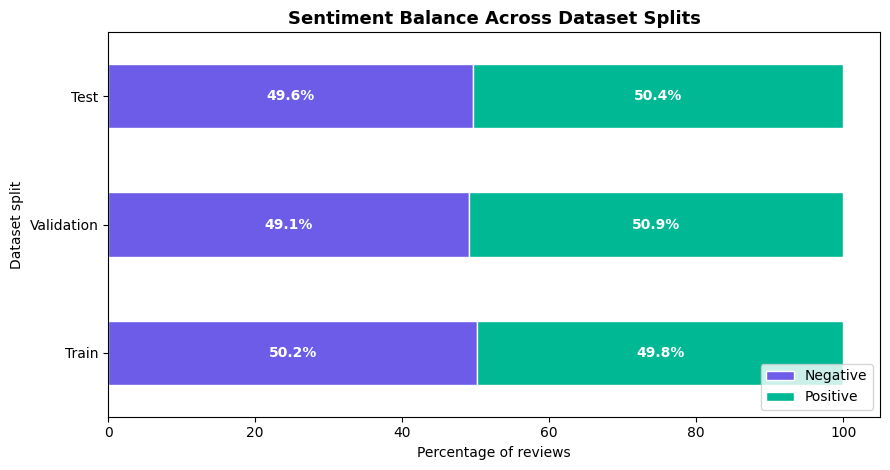

In [8]:

fig, ax = plt.subplots(figsize=(9, 4.8))
class_percent[["Negative", "Positive"]].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#6C5CE7", "#00B894"],
    edgecolor="white",
)

ax.set_title("Sentiment Balance Across Dataset Splits", fontsize=13, fontweight="bold")
ax.set_xlabel("Percentage of reviews")
ax.set_ylabel("Dataset split")
ax.legend(loc="lower right")

for i, split in enumerate(class_percent.index):
    neg = class_percent.loc[split, "Negative"]
    pos = class_percent.loc[split, "Positive"]
    ax.text(neg / 2, i, f"{neg:.1f}%", va="center", ha="center", color="white", fontweight="bold")
    ax.text(neg + pos / 2, i, f"{pos:.1f}%", va="center", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

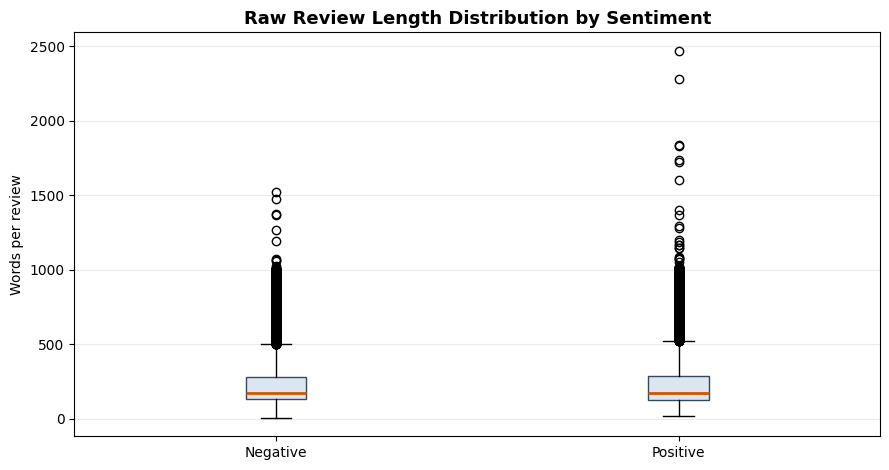

Training review length summary
count    35000.0
mean       230.7
std        171.0
min          4.0
50%        173.0
75%        280.0
85%        370.0
90%        449.0
95%        587.0
max       2470.0
Name: raw_word_count, dtype: float64


In [9]:
train_df["raw_word_count"] = train_df["review"].astype(str).str.split().apply(len)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.boxplot(
    [
        train_df.loc[train_df["sentiment"] == 0, "raw_word_count"],
        train_df.loc[train_df["sentiment"] == 1, "raw_word_count"],
    ],
    labels=["Negative", "Positive"],
    patch_artist=True,
    boxprops=dict(facecolor="#DCE6F1", color="#34495E"),
    medianprops=dict(color="#D35400", linewidth=2),
)
ax.set_title("Raw Review Length Distribution by Sentiment", fontsize=13, fontweight="bold")
ax.set_ylabel("Words per review")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Training review length summary")
print(train_df["raw_word_count"].describe(percentiles=[0.50, 0.75, 0.85, 0.90, 0.95]).round(1))

### Data Understanding

The initial analysis shows that the IMDb review dataset is suitable for binary sentiment classification. The review length analysis shows that movie reviews vary greatly in size.

This variation in review length is important for model design. Very long reviews may contain mixed opinions, detailed plot descriptions and delayed sentiment expressions.

## 3. Text Preprocessing



In [10]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never", "neither", "none"}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """Clean one review and return a lemmatized string."""
    text = str(text)
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for token in text.split():
        if token not in stop_words and len(token) > 1:
            tokens.append(lemmatizer.lemmatize(token))
    return " ".join(tokens)

In [11]:
from tqdm.auto import tqdm

tqdm.pandas()

start = time.time()
for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"Cleaning {name} reviews...")
    frame["clean_review"] = frame["review"].astype(str).progress_apply(clean_text)

print(f"Cleaning finished in {(time.time() - start) / 60:.2f} minutes")

sample_id = 5
print("\nBefore cleaning:\n", train_df.loc[sample_id, "review"][:600])
print("\nAfter cleaning:\n", train_df.loc[sample_id, "clean_review"][:600])

Cleaning train reviews...


  0%|          | 0/35000 [00:00<?, ?it/s]

Cleaning validation reviews...


  0%|          | 0/5000 [00:00<?, ?it/s]

Cleaning test reviews...


  0%|          | 0/10000 [00:00<?, ?it/s]

Cleaning finished in 0.72 minutes

Before cleaning:
 Arthur is middle aged rich 'kid' who drinks like a fish. Arthur does what he feels like and says whatever comes into his mind. He likes to boast about his riches and knows that he is a spoiled brat. He spends money on people he don't know and finds everything funny. Arthur must marry a high class girl to inherit a big fortune but he falls in love with a poor waitress Liza Minnelli (she looks really weird).<br /><br />This is a damn funny film. I watched this film because a very famous Indian film 'Sharabee' is based on the character of Arthur. Although 'Sharabee' is definitely inspired by 'Art

After cleaning:
 arthur middle aged rich kid drink like fish arthur feel like say whatever come mind like boast rich know spoiled brat spends money people not know find everything funny arthur must marry high class girl inherit big fortune fall love poor waitress liza minnelli look really weird damn funny film watched film famous indian film s

### 3.1 Cleaned Text Exploration

In [12]:
def frequent_terms(text_series, n=18):
    joined_text = " ".join(text_series.astype(str))
    counts = Counter(joined_text.split())
    return pd.DataFrame(counts.most_common(n), columns=["word", "count"])

negative_terms = frequent_terms(train_df.loc[train_df["sentiment"] == 0, "clean_review"])
positive_terms = frequent_terms(train_df.loc[train_df["sentiment"] == 1, "clean_review"])

display(negative_terms.head())
display(positive_terms.head())

,word,count
0,not,47617
1,movie,40795
2,film,30815
3,one,19092
4,like,16073


,word,count
0,not,36644
1,film,34658
2,movie,31257
3,one,19675
4,like,12529


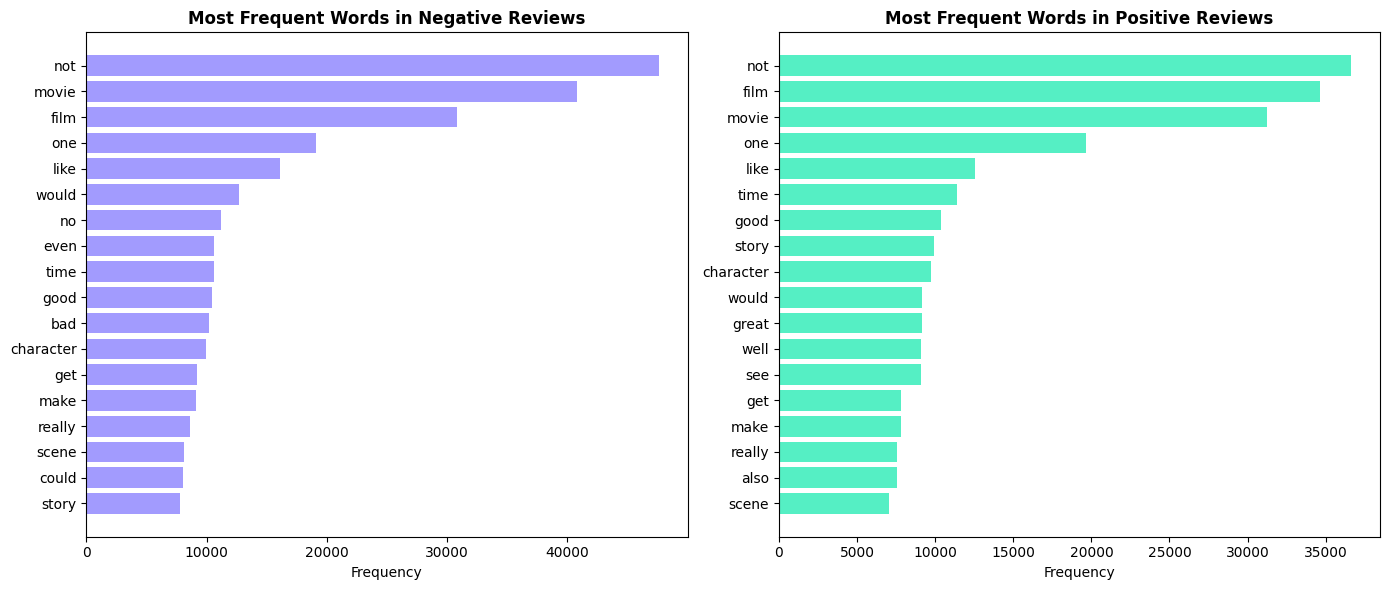

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(negative_terms["word"][::-1], negative_terms["count"][::-1], color="#A29BFE")
axes[0].set_title("Most Frequent Words in Negative Reviews", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Frequency")

axes[1].barh(positive_terms["word"][::-1], positive_terms["count"][::-1], color="#55EFC4")
axes[1].set_title("Most Frequent Words in Positive Reviews", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Tokenization and Percentile-Based Sequence Padding


In [14]:
VOCAB_SIZE = 12000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df["clean_review"])
word_index = tokenizer.word_index

train_seq = tokenizer.texts_to_sequences(train_df["clean_review"])
val_seq = tokenizer.texts_to_sequences(val_df["clean_review"])
test_seq = tokenizer.texts_to_sequences(test_df["clean_review"])

seq_lengths = np.array([len(seq) for seq in train_seq])

MAX_LEN_RNN = int(np.clip(np.percentile(seq_lengths, 65), 80, 120))
MAX_LEN_LSTM = int(np.clip(np.percentile(seq_lengths, 85), 130, 180))
MAX_LEN_GLOVE = MAX_LEN_LSTM

print("Total vocabulary discovered:", len(word_index))
print("Vocabulary retained:", VOCAB_SIZE)
print("65th percentile length:", int(np.percentile(seq_lengths, 65)))
print("85th percentile length:", int(np.percentile(seq_lengths, 85)))
print("RNN padded length:", MAX_LEN_RNN)
print("LSTM/GloVe padded length:", MAX_LEN_LSTM)

Total vocabulary discovered: 77115
Vocabulary retained: 12000
65th percentile length: 117
85th percentile length: 195
RNN padded length: 117
LSTM/GloVe padded length: 180


In [15]:
def pad_for_model(sequences, max_len):
    return pad_sequences(
        sequences,
        maxlen=max_len,
        padding="post",
        truncating="post",
    )

X_train_rnn = pad_for_model(train_seq, MAX_LEN_RNN)
X_val_rnn = pad_for_model(val_seq, MAX_LEN_RNN)
X_test_rnn = pad_for_model(test_seq, MAX_LEN_RNN)

X_train_lstm = pad_for_model(train_seq, MAX_LEN_LSTM)
X_val_lstm = pad_for_model(val_seq, MAX_LEN_LSTM)
X_test_lstm = pad_for_model(test_seq, MAX_LEN_LSTM)

X_train_glove = pad_for_model(train_seq, MAX_LEN_GLOVE)
X_val_glove = pad_for_model(val_seq, MAX_LEN_GLOVE)
X_test_glove = pad_for_model(test_seq, MAX_LEN_GLOVE)

y_train = train_df["sentiment"].values.astype("int32")
y_val = val_df["sentiment"].values.astype("int32")
y_test = test_df["sentiment"].values.astype("int32")

print("RNN train shape:", X_train_rnn.shape)
print("LSTM train shape:", X_train_lstm.shape)
print("GloVe train shape:", X_train_glove.shape)

RNN train shape: (35000, 117)
LSTM train shape: (35000, 180)
GloVe train shape: (35000, 180)


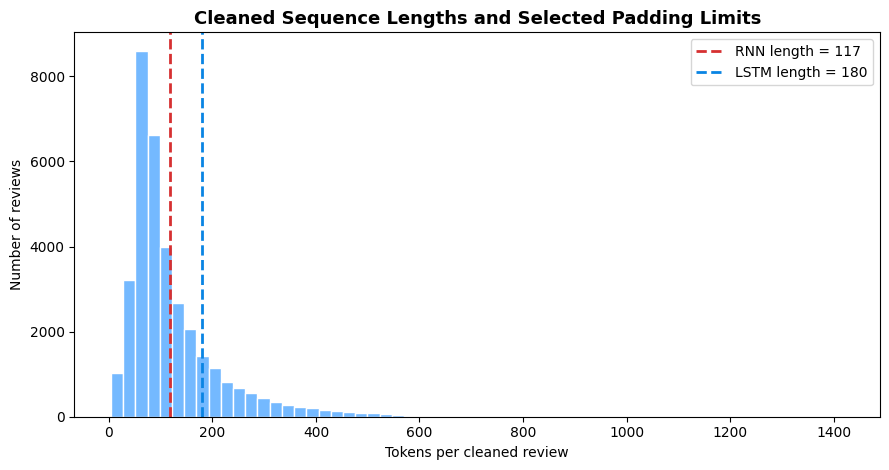

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(seq_lengths, bins=60, color="#74B9FF", edgecolor="white")
ax.axvline(MAX_LEN_RNN, color="#D63031", linestyle="--", linewidth=2, label=f"RNN length = {MAX_LEN_RNN}")
ax.axvline(MAX_LEN_LSTM, color="#0984E3", linestyle="--", linewidth=2, label=f"LSTM length = {MAX_LEN_LSTM}")
ax.set_title("Cleaned Sequence Lengths and Selected Padding Limits", fontsize=13, fontweight="bold")
ax.set_xlabel("Tokens per cleaned review")
ax.set_ylabel("Number of reviews")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model Building and Training

All three models use binary cross-entropy because the target variable has two classes: negative and positive.

In [17]:
BATCH_SIZE = 256

histories = {}
models = {}
train_times = {}


def callbacks_for_model(patience=3):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
    ]

### 5.1 Model 1 - RNN


In [18]:
rnn_model = Sequential(name="Model_1_Simple_RNN")
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=56, input_length=MAX_LEN_RNN))
rnn_model.add(SimpleRNN(48, activation="tanh", recurrent_dropout=0.25))
rnn_model.add(Dropout(0.45))
rnn_model.add(Dense(24, activation="relu"))
rnn_model.add(Dense(1, activation="sigmoid"))

rnn_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=8e-4),
    metrics=["accuracy"],
)

rnn_model.build(input_shape=(None, MAX_LEN_RNN))
rnn_model.summary()

Model: "Model_1_Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 117, 56)        │       672,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 48)             │         5,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 678,241 (2.59 MB)

 Trainable params: 678,241 (2.59 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("Training Model 1: Simple RNN")
start = time.time()

histories["RNN"] = rnn_model.fit(
    X_train_rnn,
    y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_for_model(patience=3),
    verbose=1,
)

train_times["RNN"] = time.time() - start
models["RNN"] = rnn_model
print(f"RNN training time: {train_times['RNN']:.1f} seconds")

Training Model 1: Simple RNN
Epoch 1/12
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.5011 - loss: 0.7165 - val_accuracy: 0.4926 - val_loss: 0.6981 - learning_rate: 8.0000e-04
Epoch 2/12
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5012 - loss: 0.7010 - val_accuracy: 0.4834 - val_loss: 0.6964 - learning_rate: 8.0000e-04
Epoch 3/12
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4957 - loss: 0.6985 - val_accuracy: 0.4914 - val_loss: 0.6947 - learning_rate: 8.0000e-04
Epoch 4/12
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5052 - loss: 0.6960 - val_accuracy: 0.4966 - val_loss: 0.6937 - learning_rate: 8.0000e-04
Epoch 5/12
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5008 - loss: 0.6965 - val_accuracy: 0.4888 - val_loss: 0.6948 - learning_rate: 8.0000e-04
Epoch 6/12
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5062 - loss: 0.6948
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.
137/137 ━━━━━━━━━━━━━

### RNN Reflection

The Simple RNN was used as the baseline model. Its validation accuracy stayed close to random guessing during training.

This weak performance suggests that the Simple RNN was not able to learn meaningful sentiment patterns from the review sequences. Simple RNNs are known to struggle with long-term dependencies, so they may forget important earlier words by the time the final prediction is made.

### 5.2 Model 2 - LSTM with Trainable Embedding


In [20]:
lstm_model = Sequential(name="Model_2_LSTM_Trainable_Embedding")
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN_LSTM))
lstm_model.add(LSTM(64, recurrent_dropout=0.20))
lstm_model.add(Dropout(0.35))
lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=3e-4),
    metrics=["accuracy"],
)

lstm_model.build(input_shape=(None, MAX_LEN_LSTM))
lstm_model.summary()

Model: "Model_2_LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 180, 64)        │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,137 (3.06 MB)

 Trainable params: 803,137 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("Training Model 2: LSTM with trainable embedding")
start = time.time()

histories["LSTM"] = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_for_model(patience=3),
    verbose=1,
)

train_times["LSTM"] = time.time() - start
models["LSTM"] = lstm_model
print(f"LSTM training time: {train_times['LSTM']:.1f} seconds")

Training Model 2: LSTM with trainable embedding
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 87s 590ms/step - accuracy: 0.5097 - loss: 0.6929 - val_accuracy: 0.4920 - val_loss: 0.6930 - learning_rate: 3.0000e-04
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 81s 591ms/step - accuracy: 0.6014 - loss: 0.6578 - val_accuracy: 0.7134 - val_loss: 0.5979 - learning_rate: 3.0000e-04
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 79s 578ms/step - accuracy: 0.6962 - loss: 0.6070 - val_accuracy: 0.7316 - val_loss: 0.5767 - learning_rate: 3.0000e-04
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 84s 592ms/step - accuracy: 0.6214 - loss: 0.6385 - val_accuracy: 0.6002 - val_loss: 0.6421 - learning_rate: 3.0000e-04
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.6300 - loss: 0.6348
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
137/137 ━━━━━━━━━━━━━━━━━━━━ 79s 574ms/step - accuracy: 0.6388 - loss: 0.6318 - val_accuracy: 0.5934 - val_loss: 0.6464 - learning_rate: 3.0000e-04
Epoc

### LSTM Reflection

The LSTM model improved noticeably compared with the Simple RNN. It has 803,137 trainable parameters and uses a trainable embedding layer, allowing the model to learn word representations directly from the IMDb training data. The validation accuracy reached its best value at epoch 3, where it achieved 73.16%. After this point, validation performance started to decline and early stopping restored the best weights.



### 5.3 Model 3 - LSTM with Pretrained GloVe Embeddings and Fine-Tuning


In [22]:
import gensim.downloader as api

print("Loading pretrained GloVe vectors: glove-wiki-gigaword-100")
glove_vectors = api.load("glove-wiki-gigaword-100")
print("GloVe vectors loaded.")

Loading pretrained GloVe vectors: glove-wiki-gigaword-100
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vectors loaded.


In [23]:
GLOVE_DIM = 100
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

matched_words = 0
missing_words = 0

for word, index in word_index.items():
    if index >= VOCAB_SIZE:
        continue
    if word in glove_vectors:
        embedding_matrix[index] = glove_vectors[word]
        matched_words += 1
    else:
        missing_words += 1

coverage = matched_words / (matched_words + missing_words) * 100
print("Words matched in GloVe:", matched_words)
print("Words missing from GloVe:", missing_words)
print(f"Embedding coverage: {coverage:.2f}%")

Words matched in GloVe: 11986
Words missing from GloVe: 13
Embedding coverage: 99.89%


In [24]:
glove_lstm_model = Sequential(name="Model_3_LSTM_GloVe_Finetuned")
glove_lstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN_GLOVE,
        trainable=True,
    )
)
glove_lstm_model.add(LSTM(72, recurrent_dropout=0.15))
glove_lstm_model.add(Dropout(0.30))
glove_lstm_model.add(Dense(32, activation="relu"))
glove_lstm_model.add(Dense(1, activation="sigmoid"))

glove_lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"],
)

glove_lstm_model.build(input_shape=(None, MAX_LEN_GLOVE))
glove_lstm_model.summary()

Model: "Model_3_LSTM_GloVe_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 180, 100)       │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72)             │        49,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,252,193 (4.78 MB)

 Trainable params: 1,252,193 (4.78 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
print("Training Model 3: LSTM with fine-tuned GloVe embeddings")
start = time.time()

histories["LSTM_GloVe"] = glove_lstm_model.fit(
    X_train_glove,
    y_train,
    validation_data=(X_val_glove, y_val),
    epochs=20,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_for_model(patience=4),
    verbose=1,
)

train_times["LSTM_GloVe"] = time.time() - start
models["LSTM_GloVe"] = glove_lstm_model
print(f"LSTM + GloVe training time: {train_times['LSTM_GloVe']:.1f} seconds")

Training Model 3: LSTM with fine-tuned GloVe embeddings
Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy: 0.5095 - loss: 0.6926 - val_accuracy: 0.5048 - val_loss: 0.6910 - learning_rate: 1.0000e-04
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 78s 570ms/step - accuracy: 0.5259 - loss: 0.6887 - val_accuracy: 0.5306 - val_loss: 0.6815 - learning_rate: 1.0000e-04
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 583ms/step - accuracy: 0.6088 - loss: 0.6590 - val_accuracy: 0.7172 - val_loss: 0.5906 - learning_rate: 1.0000e-04
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 584ms/step - accuracy: 0.6882 - loss: 0.6153 - val_accuracy: 0.7540 - val_loss: 0.5543 - learning_rate: 1.0000e-04
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 78s 569ms/step - accuracy: 0.7107 - loss: 0.5991 - val_accuracy: 0.7584 - val_loss: 0.5467 - learning_rate: 1.0000e-04
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 580ms/step - accuracy: 0.7056 - loss: 0.6038 - val_accuracy: 0.7260 - val_loss: 0.6096 - learning_rate: 1

### Fine-Tuned GloVe LSTM Reflection

The fine-tuned GloVe LSTM was the strongest model. It used pretrained 100-dimensional GloVe word vectors. This gave the model a stronger starting point than learning embeddings from scratch.

Despite the higher computational cost, it achieved the best validation performance, with the best validation accuracy reaching 79.30% at epoch 19.

## 6. Training History Visualisation



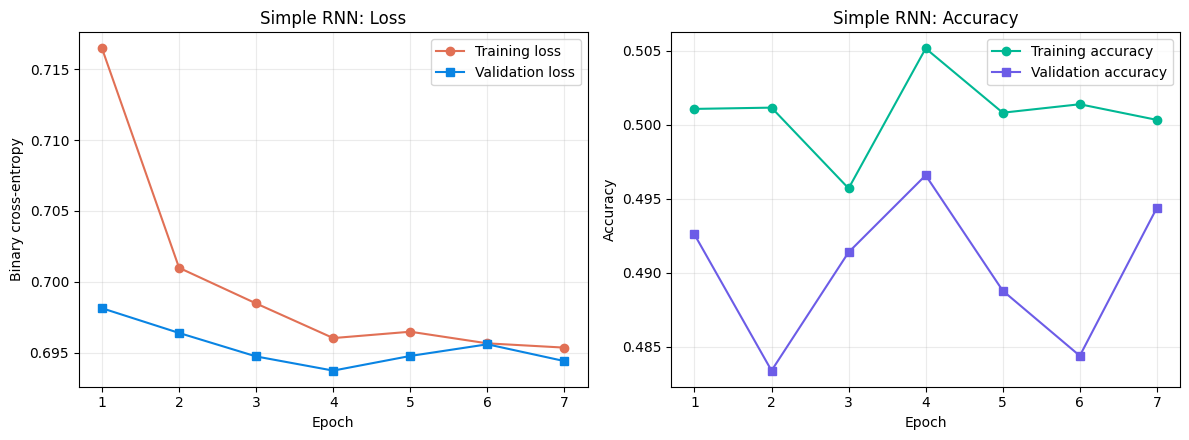

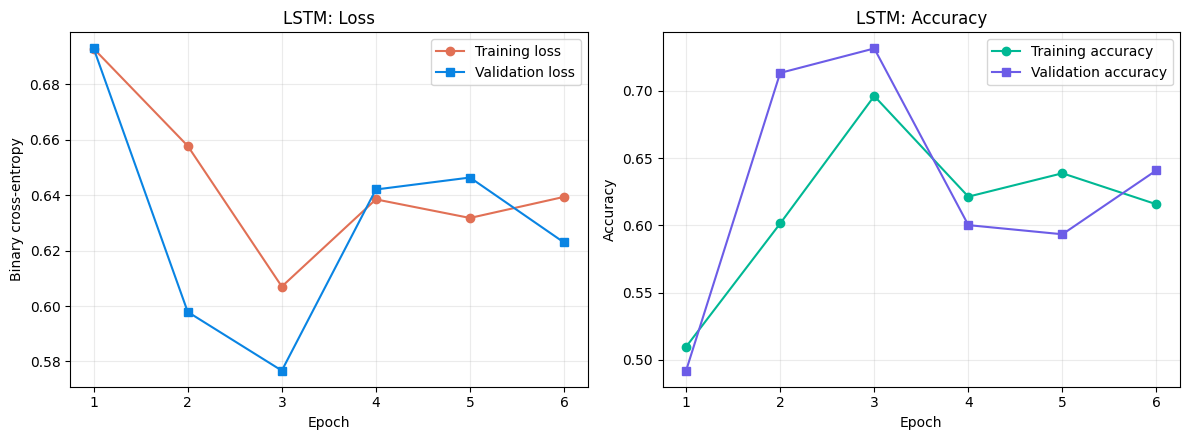

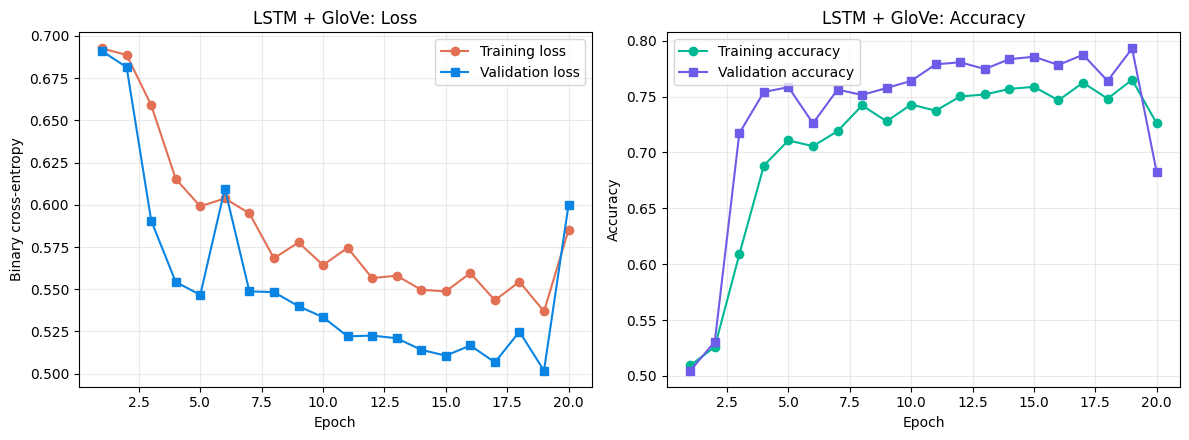

In [26]:
def plot_training_curve(history, model_title):
    epochs = range(1, len(history.history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history.history["loss"], marker="o", label="Training loss", color="#E17055")
    axes[0].plot(epochs, history.history["val_loss"], marker="s", label="Validation loss", color="#0984E3")
    axes[0].set_title(f"{model_title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, history.history["accuracy"], marker="o", label="Training accuracy", color="#00B894")
    axes[1].plot(epochs, history.history["val_accuracy"], marker="s", label="Validation accuracy", color="#6C5CE7")
    axes[1].set_title(f"{model_title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_training_curve(histories["RNN"], "Simple RNN")
plot_training_curve(histories["LSTM"], "LSTM")
plot_training_curve(histories["LSTM_GloVe"], "LSTM + GloVe")

## 7. Evaluation on the Test Set

In [27]:
def evaluate_classifier(model, X_test, y_true, model_name):
    prob_positive = model.predict(X_test, verbose=0).ravel()
    predicted = (prob_positive >= 0.50).astype(int)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Accuracy : {accuracy_score(y_true, predicted):.4f}")
    print(f"Precision: {precision_score(y_true, predicted):.4f}")
    print(f"Recall   : {recall_score(y_true, predicted):.4f}")
    print(f"F1-score : {f1_score(y_true, predicted):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, predicted, target_names=["Negative", "Positive"]))

    return predicted, prob_positive

predictions = {}
probabilities = {}

predictions["RNN"], probabilities["RNN"] = evaluate_classifier(
    rnn_model, X_test_rnn, y_test, "Model 1 - Simple RNN"
)
predictions["LSTM"], probabilities["LSTM"] = evaluate_classifier(
    lstm_model, X_test_lstm, y_test, "Model 2 - LSTM with Trainable Embedding"
)
predictions["LSTM_GloVe"], probabilities["LSTM_GloVe"] = evaluate_classifier(
    glove_lstm_model, X_test_glove, y_test, "Model 3 - LSTM with Fine-Tuned GloVe"
)


Model 1 - Simple RNN
Accuracy : 0.4956
Precision: 0.4968
Recall   : 0.0778
F1-score : 0.1345

Classification report:
              precision    recall  f1-score   support

    Negative       0.50      0.92      0.64      4961
    Positive       0.50      0.08      0.13      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.39     10000
weighted avg       0.50      0.50      0.39     10000


Model 2 - LSTM with Trainable Embedding
Accuracy : 0.7187
Precision: 0.7677
Recall   : 0.6335
F1-score : 0.6941

Classification report:
              precision    recall  f1-score   support

    Negative       0.68      0.81      0.74      4961
    Positive       0.77      0.63      0.69      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000


Model 3 - LSTM with Fine-Tuned GloVe
Accuracy : 0.7831
Precision: 0.7741
Recall   : 0.8043

### Test Result

The test set results show a clear ranking between the three models. The Simple RNN achieved only 49.56% accuracy, which is almost the same as random guessing for a balanced binary classification task. Its recall for the positive class was only 0.0778, meaning it failed to identify most positive reviews. This confirms that the Simple RNN was not suitable for this task.

The LSTM model achieved 71.87% accuracy, with a precision of 0.7677, recall of 0.6335 and F1-score of 0.6941. This is a major improvement over the Simple RNN and shows that the LSTM successfully captured more useful sequential information. However, its recall was lower than its precision, meaning it was more conservative when predicting positive reviews.

The fine-tuned GloVe LSTM achieved the best overall result, with 78.31% accuracy, 0.7741 precision, 0.8043 recall and 0.7889 F1-score. This model performed more consistently across both classes and showed the best balance between identifying positive reviews and avoiding false predictions. Therefore, the fine-tuned GloVe LSTM is selected as the best model for the final prediction interface and error analysis.

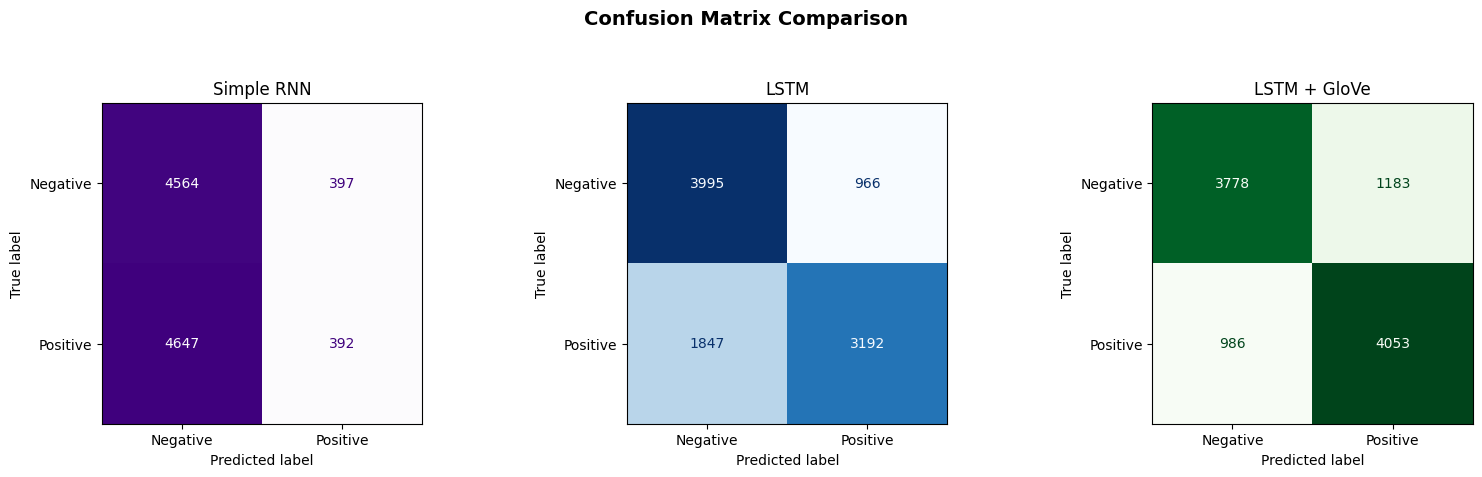

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cmaps = ["Purples", "Blues", "Greens"]
model_titles = {
    "RNN": "Simple RNN",
    "LSTM": "LSTM",
    "LSTM_GloVe": "LSTM + GloVe",
}

for ax, key, cmap in zip(axes, ["RNN", "LSTM", "LSTM_GloVe"], cmaps):
    cm = confusion_matrix(y_test, predictions[key])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format="d")
    ax.set_title(model_titles[key])

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [29]:
summary_rows = []
for key, label in [
    ("RNN", "Simple RNN"),
    ("LSTM", "LSTM - trainable embedding"),
    ("LSTM_GloVe", "LSTM + fine-tuned GloVe"),
]:
    pred = predictions[key]
    summary_rows.append({
        "Model": label,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "Training time (s)": train_times[key],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
display(summary_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "Training time (s)": "{:.1f}",
}))

,Model,Accuracy,Precision,Recall,F1-score,Training time (s)
2,LSTM + fine-tuned GloVe,0.7831,0.7741,0.8043,0.7889,1605.3
1,LSTM - trainable embedding,0.7187,0.7677,0.6335,0.6941,490.9
0,Simple RNN,0.4956,0.4968,0.0778,0.1345,22.8


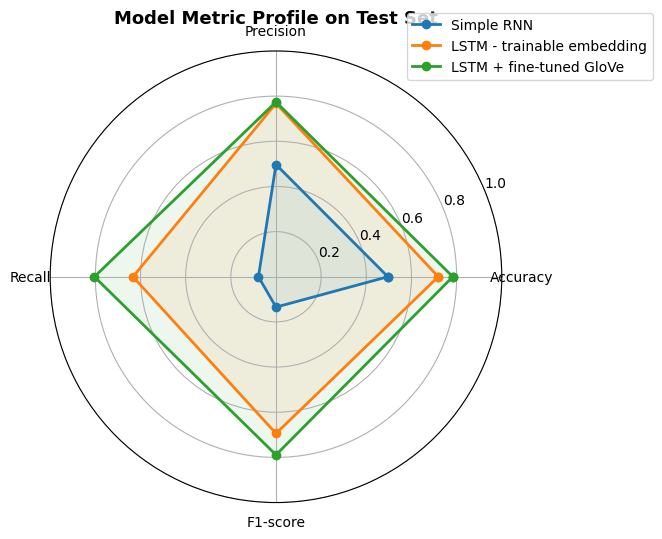

In [30]:

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
plot_df = summary_df.set_index("Model").loc[
    ["Simple RNN", "LSTM - trainable embedding", "LSTM + fine-tuned GloVe"],
    metrics_to_plot,
]

angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for model_name, values in plot_df.iterrows():
    vals = values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, marker="o", linewidth=2, label=model_name)
    ax.fill(angles, vals, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title("Model Metric Profile on Test Set", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))
plt.tight_layout()
plt.show()

### 7.1 Result Interpretation

The Simple RNN performs the weakest because it has difficulty retaining long-distance context in lengthy movie reviews. The LSTM model performs better because its gate structure handles sequence memory more effectively. The fine-tuned GloVe LSTM perform best because it starts with pretrained semantic word representations and then adapts them to the IMDb sentiment task.

## 8. Error Analysis

This section inspects two to three misclassified reviews from the best-performing model. The analysis focuses on the difference between model complexity and actual performance.

In [32]:
best_key = max(acc, key=acc.get)
best_model_name = model_titles[best_key]
print("Best model selected for error analysis:", best_model_name)

error_df = test_df[["review", "clean_review", "sentiment"]].copy()
error_df["predicted"] = predictions[best_key]
error_df["prob_positive"] = probabilities[best_key]
error_df["actual_label"] = error_df["sentiment"].map(label_names)
error_df["predicted_label"] = error_df["predicted"].map(label_names)
error_df["confidence"] = np.where(
    error_df["predicted"] == 1,
    error_df["prob_positive"],
    1 - error_df["prob_positive"],
)

misclassified = error_df[error_df["sentiment"] != error_df["predicted"]].copy()
print(f"Misclassified reviews: {len(misclassified)} out of {len(error_df)}")
print(f"Error rate: {len(misclassified) / len(error_df) * 100:.2f}%")

# Show high-confidence mistakes.
examples = misclassified.sort_values("confidence", ascending=False).head(3)

display(examples[["actual_label", "predicted_label", "prob_positive", "confidence", "review"]])

Best model selected for error analysis: LSTM + GloVe
Misclassified reviews: 2169 out of 10000
Error rate: 21.69%


,actual_label,predicted_label,prob_positive,confidence,review
4219,Negative,Positive,0.876072,0.876072,Steven Vasquez directed and co-wrote with Jame...
6230,Negative,Positive,0.867940,0.867940,I am normally a Spike Lee fan. It takes some t...
1886,Negative,Positive,0.859733,0.859733,This film wasn't good at all. I was able to ca...


## 9. Real-Time Sentiment Prediction Interface


In [34]:
import gradio as gr


def vectorise_single_review(review, model_key):
    cleaned = clean_text(review)
    seq = tokenizer.texts_to_sequences([cleaned])

    if model_key == "RNN":
        return pad_for_model(seq, MAX_LEN_RNN)
    if model_key == "LSTM":
        return pad_for_model(seq, MAX_LEN_LSTM)
    return pad_for_model(seq, MAX_LEN_GLOVE)


def predict_review_sentiment(review):
    if not str(review).strip():
        return "Please enter a movie review.", 0.0, ""

    x_input = vectorise_single_review(review, best_key)
    selected_model = models[best_key]
    prob_pos = float(selected_model.predict(x_input, verbose=0)[0][0])

    label = "Positive" if prob_pos >= 0.5 else "Negative"
    confidence = prob_pos if label == "Positive" else 1 - prob_pos
    cleaned = clean_text(review)

    return label, round(confidence, 4), cleaned

interface = gr.Interface(
    fn=predict_review_sentiment,
    inputs=gr.Textbox(lines=6, label="Enter a movie review"),
    outputs=[
        gr.Label(label="Predicted sentiment"),
        gr.Number(label="Confidence"),
        gr.Textbox(label="Cleaned text used by the model"),
    ],
    title="IMDb Sentiment Classifier",
    description=f"Real-time prediction using the best model from this run: {best_model_name}",
)

interface.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 10. Conclusion

This notebook implemented the required end-to-end sentiment classification pipeline. The Simple RNN provides a baseline but performs the worst because long IMDb reviews contain dependencies that are hard for a plain recurrent unit to preserve. The LSTM improves performance by using gates to manage longer sequence information. The fine-tuned GloVe LSTM performs best because pretrained embeddings provide stronger starting word representations and the model can adapt them during training.

Future improvements could include broader hyperparameter tuning, threshold optimisation, stronger embeddings, bidirectional recurrent layers, or transformer-based text classifiers after completing the required RNN/LSTM comparison.